# Exploratory Data Analysis – EDA
Phân tích bộ dữ liệu điểm thi THPT từ 2022-2025.

## 1. Setup & Load Data

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")
import viz

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

In [2]:
df = viz.load_data("../data/processed/final_data.csv")
print("Shape:", df.shape)

Shape: (4227695, 28)


In [3]:
df.head()

,nam,chuong_trinh,sbd,ma_tinh,ten_tinh,vung_mien,vung_3,ma_ngoai_ngu,toan,ngu_van,...,cong_nghe_cn,cong_nghe_nn,gd_ktpl,so_mon,ban,diem_khoi_a00,diem_khoi_a01,diem_khoi_b00,diem_khoi_c00,diem_khoi_d01
0,2022,2006,01000001,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,3.6,5.00,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,13.75,12.60
1,2022,2006,01000002,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,8.4,6.75,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,22.75,22.75
2,2022,2006,01000003,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,5.8,7.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,20.25,18.30
3,2022,2006,01000004,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,7.4,7.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,21.50,23.50
4,2022,2006,01000005,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,7.2,8.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,25.00,24.70


## 2. Tổng quan & dữ liệu thiếu
Quan sát tỷ lệ dữ liệu bị khuyết (nghĩa là không dự thi môn đó) và phân bố tổng số môn thi của các thí sinh.

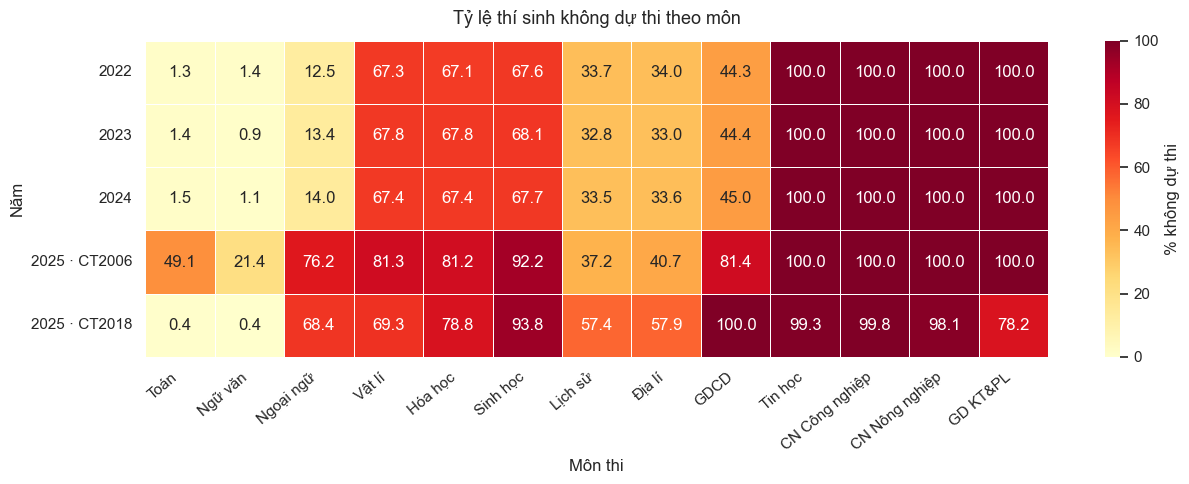

In [13]:
viz.plot_missing_heatmap(df)
plt.show()

**Nhận xét.**

- **Toán và Ngữ văn** phủ gần như toàn bộ thí sinh (khuyết ~1–1.5% giai đoạn 2022–2024) — hai môn bắt buộc.
- **Bộ ba KHTN (Lý/Hóa/Sinh) khuyết ~67–68%**, trong khi **bộ ba KHXH (Sử/Địa/GDCD) khuyết ~33–45%** suốt 2022–2024: phần lớn thí sinh nghiêng về ban KHXH, số chọn KHTN chỉ khoảng một nửa.
- **2025 phân hóa rõ giữa hai chương trình:**
  - **CT2006 (2025)**: khuyết rất cao ở mọi môn (Toán 49.1%, Ngữ văn 21.4%) — nhóm thí sinh tự do, chủ yếu thi lại vài môn.
  - **CT2018 (2025)**: Toán/Văn phủ gần tuyệt đối (~0.4%), nhưng **GDCD khuyết 100%** và các môn mới **Tin học, Công nghệ CN/NN, GD KT&PL** khuyết 78–99.8%.
- **Ngoại ngữ** tăng dần tỉ lệ khuyết theo thời gian: 12.5% (2022) → 14.0% (2024) → 68.4% ở CT2018 (2025), khi môn này không còn bắt buộc trong chương trình mới.

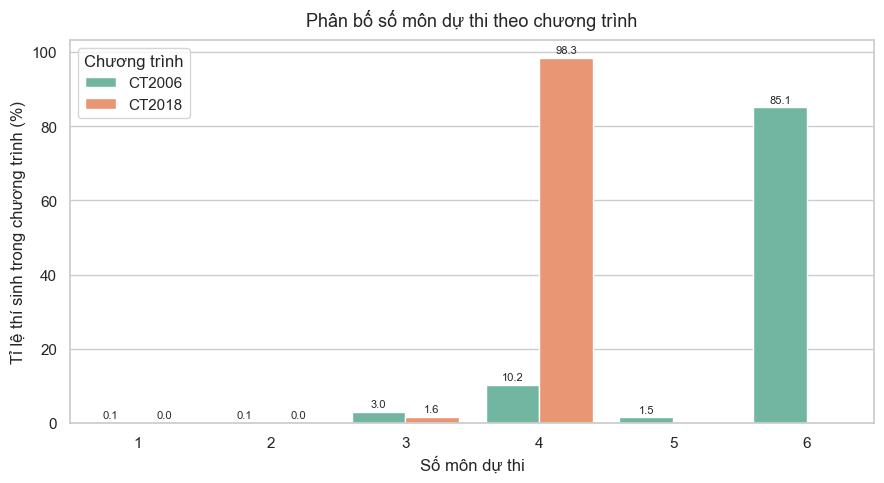

In [15]:
viz.plot_so_mon_dist(df)
plt.show()

**Nhận xét.**

- **CT2006** tập trung ở **6 môn (85.1%)** — thí sinh thi đủ Toán, Văn, Ngoại ngữ và trọn một tổ hợp KHTN hoặc KHXH. Nhóm 4 môn (10.2%) và 5 môn (1.5%) chủ yếu là thí sinh tự do thi để xét tuyển.
- **CT2018** dồn gần như tuyệt đối vào **4 môn (98.3%)** — đúng cấu trúc chương trình mới: 2 môn bắt buộc + 2 môn tự chọn.
- Hai chương trình có **mức nền số môn khác hẳn nhau** (6 vs 4), nên mọi so sánh tổng/điểm trung bình cộng giữa thí sinh CT2006 và CT2018 đều không cùng cơ sở.
- Tỉ lệ thi 1–2 môn gần như bằng 0 ở cả hai chương trình.

## 3. Phổ điểm từng môn
Phân tích chi tiết phổ điểm, điểm liệt (<1).

In [16]:
display(viz.summary_score_by_subject_year(df))

,Năm,Môn,Số lượng thí sinh,Mean,Median,Std,% < 1 (Điểm liệt),% >= 8 (Khá giỏi),% = 10 (Tuyệt đối)
0,2022,GDCD,554343,8.033266,8.25,1.067272,0.004510,61.850154,0.511597
1,2022,Hóa học,327367,6.703898,7.00,1.600393,0.006109,27.872693,0.048264
2,2022,Lịch sử,659662,6.343930,6.50,1.612879,0.003335,18.130649,0.269684
3,2022,Ngoại ngữ,870609,5.157686,4.80,1.949547,0.016885,12.090043,0.063748
4,2022,Ngữ văn,981407,6.507746,6.50,1.379602,0.016914,16.972367,0.000509
5,2022,Sinh học,322198,5.019109,4.75,1.448270,0.014587,4.590035,0.001552
6,2022,Toán,982726,6.466254,6.80,1.675435,0.005597,21.849122,0.003562
7,2022,Vật lí,325523,6.723779,7.00,1.441925,0.003379,22.746473,0.047308
8,2022,Địa lí,657421,6.677929,6.75,1.215013,0.005172,16.726877,0.024794
9,2023,GDCD,565452,8.285805,8.50,1.137638,0.004244,68.954748,2.598452


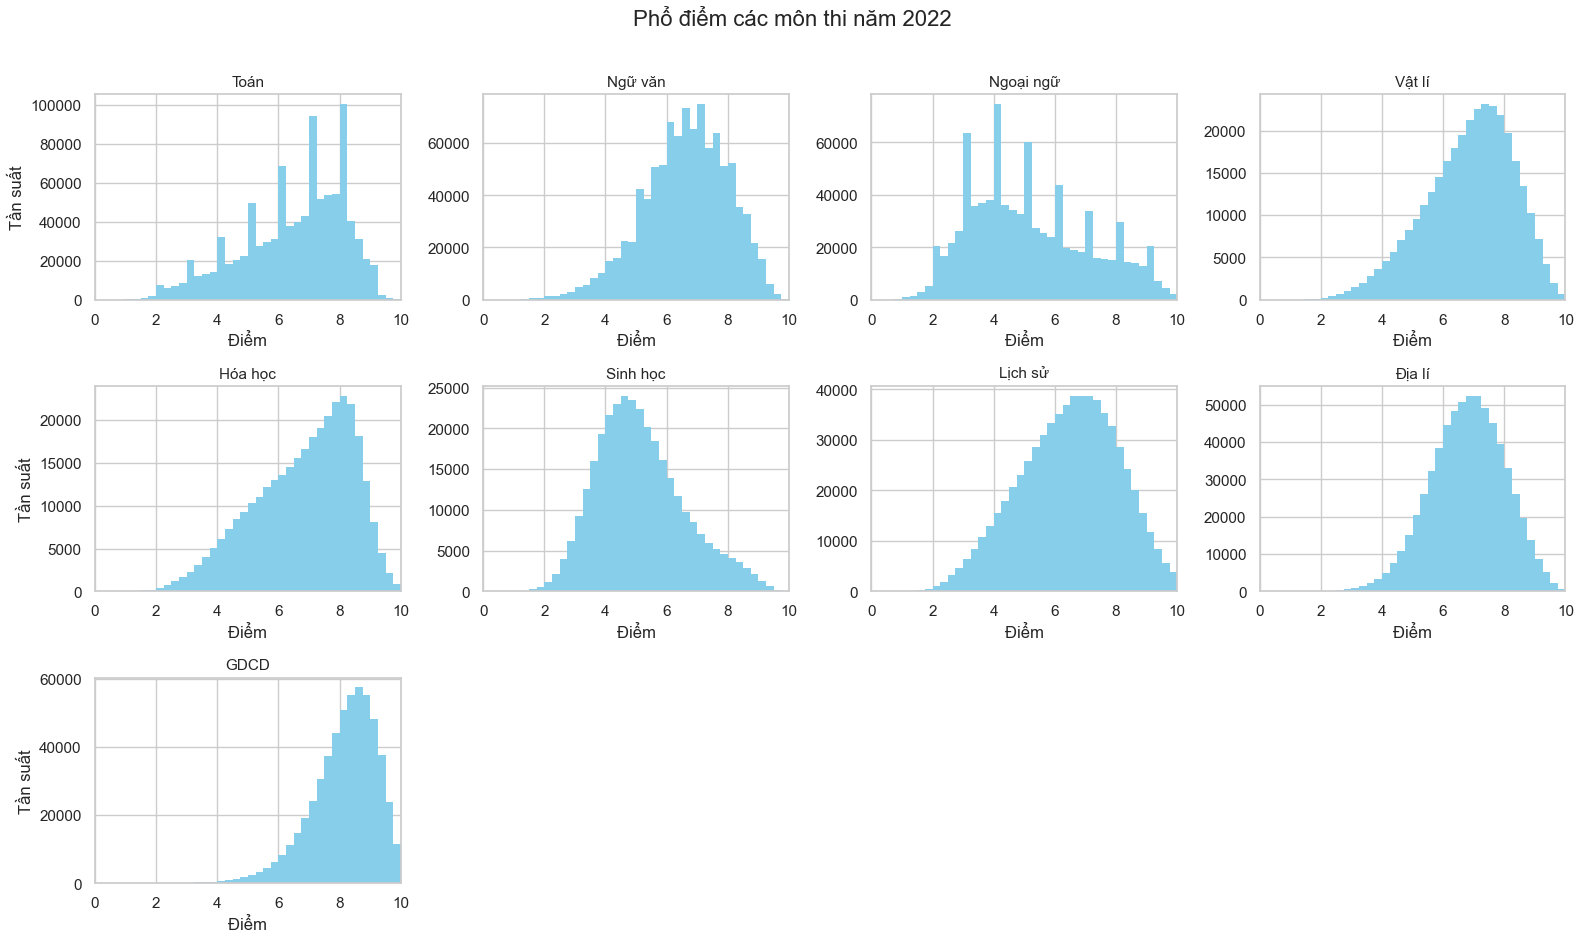

In [18]:
viz.plot_score_hist_grid(df, year=2022)
plt.show()

**Nhận xét, phổ điểm năm 2022.**

Phổ điểm hai môn Toán và Ngoại ngữ xuất hiện hiện tượng "răng cưa", với một số mức điểm có tần suất cao đột biến so với các mức lân cận. Đây là đặc trưng thường gặp ở các môn thi trắc nghiệm, do điểm được quy đổi từ số câu trả lời đúng nên một số giá trị điểm tập trung nhiều thí sinh hơn.

Trong các môn, Ngoại ngữ có phân bố kém cân đối nhất: phần lớn thí sinh đạt điểm trong khoảng 3–5, chỉ một bộ phận nhỏ đạt 8–10, tạo thành phổ lệch trái và có xu hướng tách thành hai cụm. Điều này phản ánh sự chênh lệch đáng kể về năng lực ngoại ngữ giữa các nhóm thí sinh. Môn Lịch sử cũng có mặt bằng điểm thấp, tập trung chủ yếu trong khoảng 4–6 với đỉnh phân bố thấp và trải rộng.

Ở chiều ngược lại, GDCD là môn có điểm cao nhất, với phần lớn thí sinh đạt 7–9 và gần như không có điểm thấp. Các môn Vật lí, Hóa học và Địa lí có phân bố tương đối cân đối, đỉnh nằm trong khoảng 7–8. Riêng Sinh học là môn thuộc nhóm khoa học tự nhiên nhưng có mặt bằng điểm thấp, phần lớn thí sinh chỉ đạt 4–5 điểm.

Ngữ văn có phân bố liên tục, không xuất hiện hiện tượng răng cưa, điểm tập trung quanh khoảng 6–7.

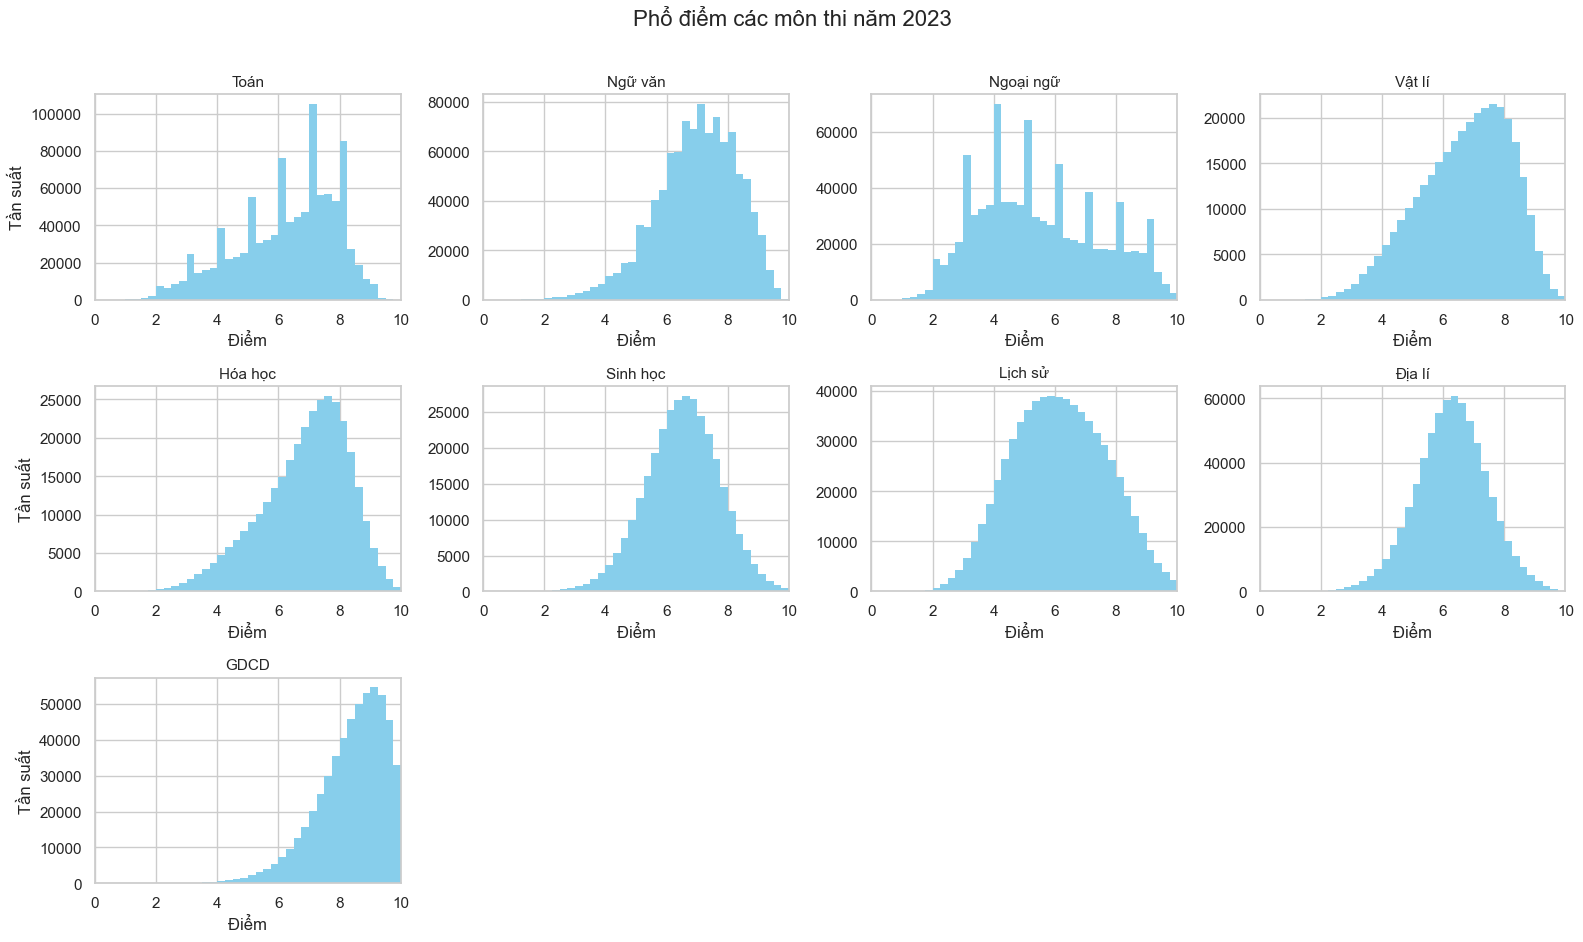

In [19]:
viz.plot_score_hist_grid(df, year=2023)
plt.show()

**Nhận xét, phổ điểm năm 2023.**

Phổ điểm năm 2023 nhìn chung giữ nguyên các đặc trưng đã thấy ở năm 2022. Hai môn Toán và Ngoại ngữ tiếp tục xuất hiện hiện tượng răng cưa, với một số mức điểm có tần suất cao đột biến so với các mức lân cận, do đặc thù quy đổi điểm của hình thức thi trắc nghiệm.

Ngoại ngữ vẫn là môn có phân bố kém cân đối nhất, điểm tập trung chủ yếu trong khoảng 3 đến 5 và chỉ một bộ phận nhỏ đạt 8 đến 10, tạo thành phổ lệch trái và có xu hướng tách cụm. Môn Lịch sử có mặt bằng điểm thấp, tập trung quanh khoảng 5 đến 6 với đỉnh phân bố thấp và trải rộng, tuy nhiên đã nhích cao hơn đôi chút so với năm 2022.

GDCD tiếp tục là môn có điểm cao nhất, phần lớn thí sinh đạt 8 đến 10 và gần như không có điểm thấp. Các môn Vật lí, Hóa học và Địa lí có phân bố tương đối cân đối, đỉnh nằm trong khoảng 7 đến 8. Riêng Sinh học năm nay có cải thiện rõ so với 2022, phổ điểm cân đối hơn và đỉnh dịch lên khoảng 6 đến 7, thay vì dồn ở vùng điểm thấp 4 đến 5 như năm trước.

Ngữ văn duy trì phân bố liên tục, không xuất hiện răng cưa, điểm tập trung quanh khoảng 6 đến 8.

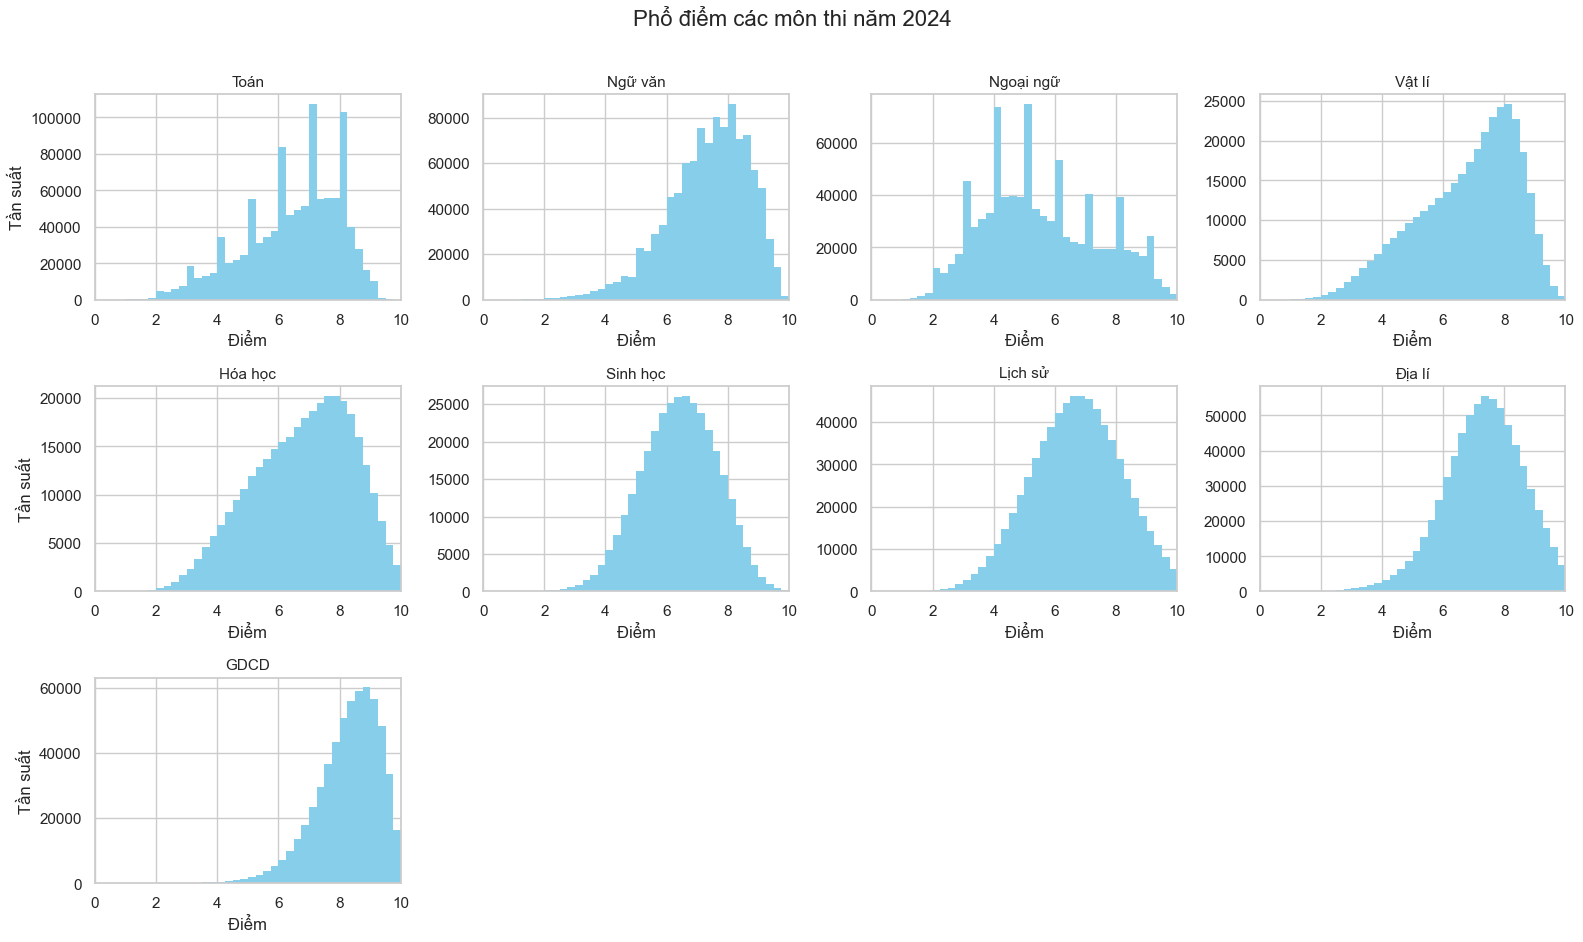

In [20]:
viz.plot_score_hist_grid(df, year=2024)
plt.show()

**Nhận xét, phổ điểm năm 2024.**

Phổ điểm năm 2024 tiếp tục duy trì các đặc trưng chung của giai đoạn 2022 đến 2024. Hai môn Toán và Ngoại ngữ vẫn xuất hiện hiện tượng răng cưa, với một số mức điểm có tần suất cao đột biến so với các mức lân cận, do đặc thù quy đổi điểm của hình thức thi trắc nghiệm.

Ngoại ngữ vẫn là môn có phân bố kém cân đối nhất, điểm tập trung chủ yếu trong khoảng 3 đến 5 và chỉ một bộ phận nhỏ đạt 8 đến 10, giữ nguyên dáng phổ lệch trái và có xu hướng tách cụm như các năm trước. Môn Lịch sử có sự cải thiện rõ rệt so với 2022 và 2023, phổ điểm cân đối hơn và đỉnh dịch lên khoảng 6 đến 7, không còn lệch hẳn về vùng điểm thấp.

GDCD tiếp tục là môn có điểm cao nhất, phần lớn thí sinh đạt 8 đến 10 và gần như không có điểm thấp. Các môn Vật lí, Hóa học, Sinh học và Địa lí có phân bố tương đối cân đối, đỉnh nằm trong khoảng 7 đến 8, trong đó Sinh học giữ được mặt bằng điểm ổn định tương tự năm 2023.

Ngữ văn duy trì phân bố liên tục, không xuất hiện răng cưa, điểm tập trung quanh khoảng 7 đến 8 và có xu hướng nhích nhẹ về phía điểm cao so với các năm trước.

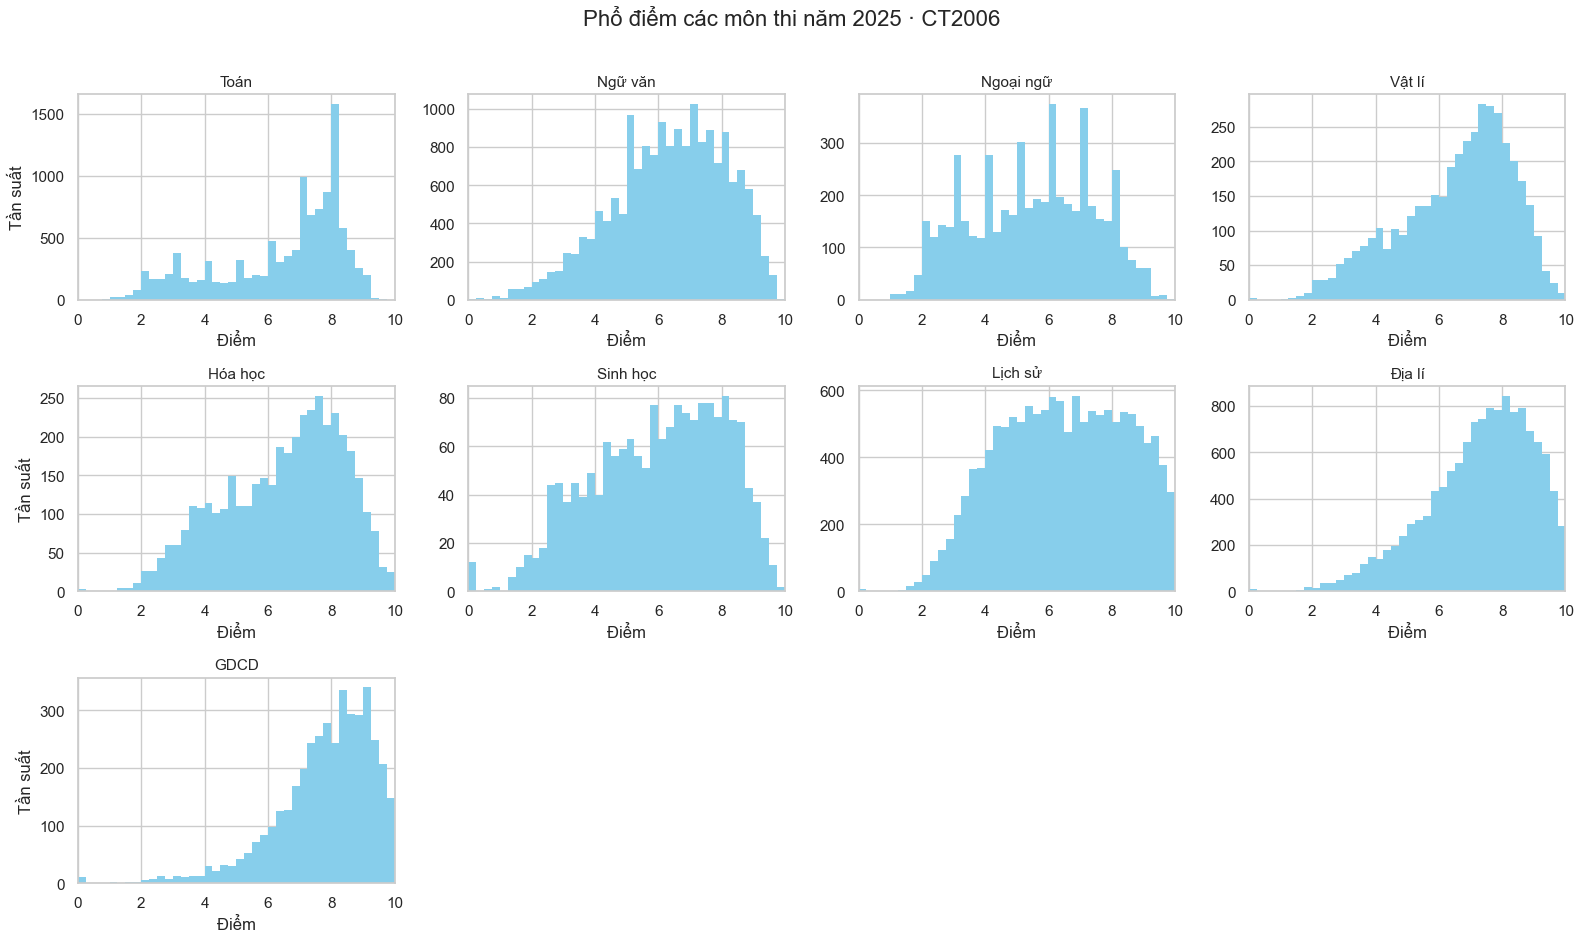

In [23]:
viz.plot_score_hist_grid(df, year=2025, chuong_trinh="2006")
plt.show()

**Nhận xét, phổ điểm năm 2025, chương trình 2006.**

Đây là nhóm thí sinh tự do thi theo đề chương trình 2006 trong năm 2025, với quy mô rất nhỏ (khoảng 22 nghìn thí sinh) và tỷ lệ dự thi từng môn thấp. Do số lượng ít, phổ điểm các môn gồ ghề và nhiễu hơn nhiều so với các năm trước, vì vậy chỉ nên xem xét ở mức xu hướng chung, không so sánh trực tiếp về tần suất với các năm có quy mô hàng triệu thí sinh.

Về hình dạng, phổ điểm vẫn giữ các đặc trưng quen thuộc của đề chương trình 2006. Toán và Ngoại ngữ tiếp tục có hiện tượng răng cưa rõ rệt do đặc thù thi trắc nghiệm. Ngoại ngữ vẫn lệch về vùng điểm thấp và phân tán rộng. GDCD nghiêng hẳn về phía điểm cao, tập trung ở khoảng 8 đến 10.

Điểm khác biệt đáng chú ý là mặt bằng điểm của nhóm này nhìn chung thấp hơn và phân tán hơn so với thí sinh chính quy các năm trước, thể hiện ở phần đuôi điểm thấp dày hơn ở hầu hết các môn. Đặc điểm này phù hợp với tính chất của nhóm thí sinh tự do, vốn không đại diện cho mặt bằng chung của toàn bộ thí sinh dự thi.

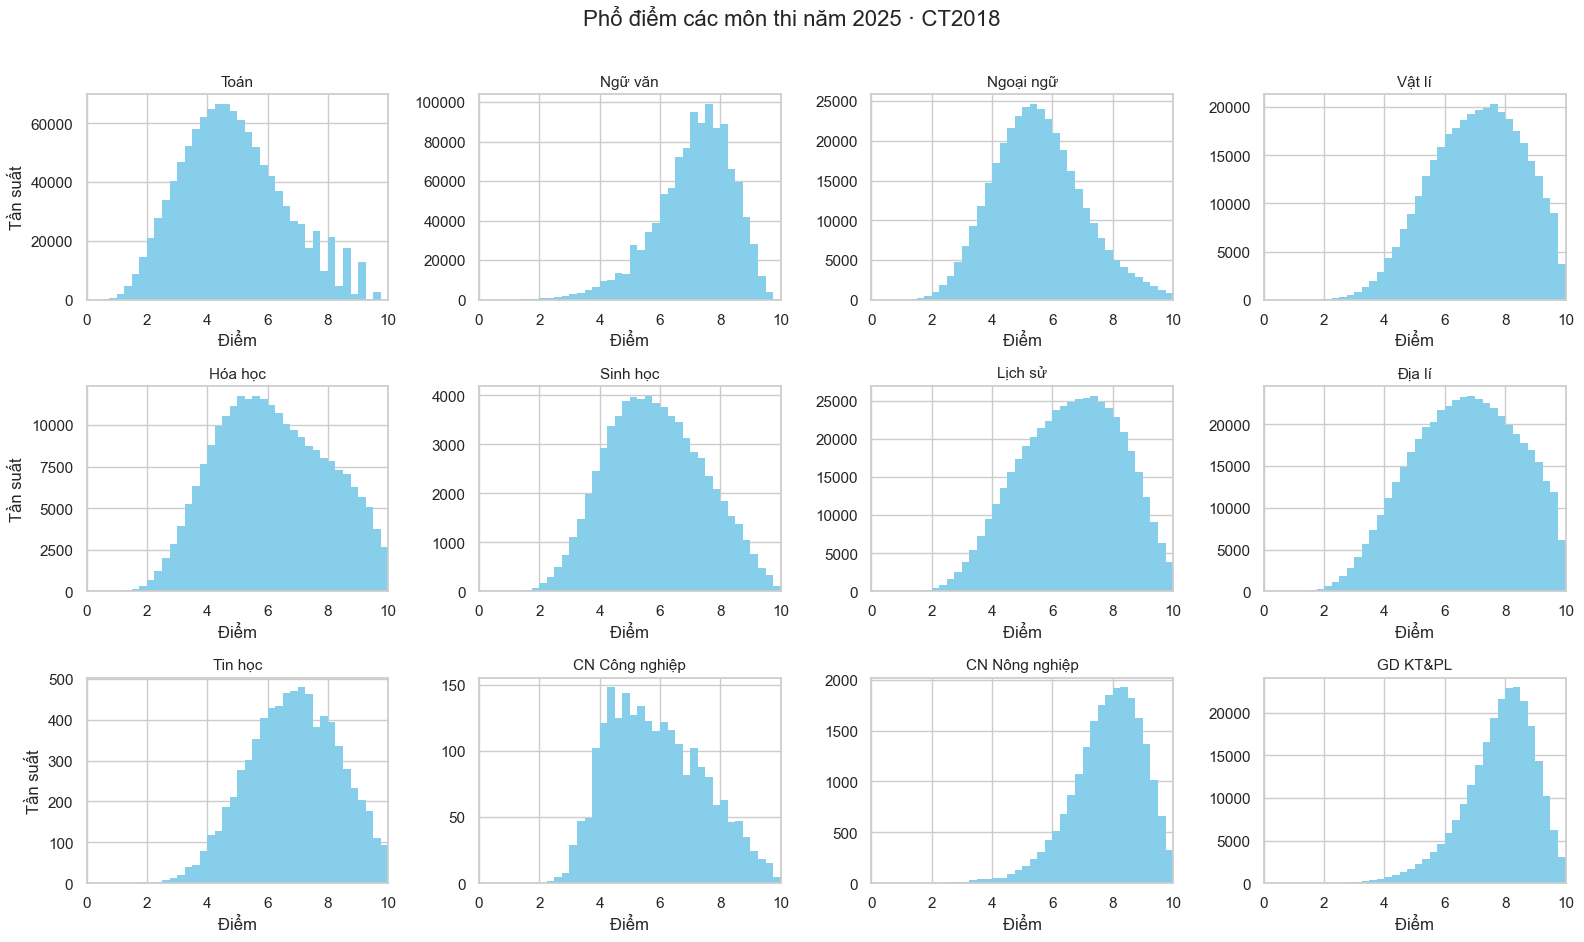

In [22]:
viz.plot_score_hist_grid(df, year=2025, chuong_trinh="2018")
plt.show()

**Nhận xét, phổ điểm năm 2025, chương trình 2018.**

Đây là năm đầu tiên kỳ thi tổ chức theo chương trình giáo dục phổ thông 2018, với cấu trúc môn thi và đề thi khác hẳn giai đoạn 2022 đến 2024, nên phổ điểm năm này được phân tích riêng và không so sánh trực tiếp về mặt bằng điểm với các năm trước. So với đề chương trình 2006, một thay đổi dễ thấy là hiện tượng răng cưa ở các môn trắc nghiệm gần như không còn, phổ điểm liền mạch và mượt hơn, phản ánh cách ra đề và tính điểm của chương trình mới.

Toán có sự thay đổi rõ rệt nhất: phổ điểm lệch hẳn về vùng điểm thấp, đỉnh rơi vào khoảng 4 đến 5 và đuôi phải mỏng dần, cho thấy mặt bằng điểm Toán năm 2025 thấp hơn đáng kể so với các năm trước. Ngoại ngữ và Vật lí có phân bố tương đối cân đối quanh khoảng 5 đến 7. Sinh học và Lịch sử trải rộng, đỉnh nằm ở vùng điểm trung bình khá.

Ở chiều ngược lại, Ngữ văn và nhóm môn mới gồm Công nghệ nông nghiệp và Giáo dục kinh tế và pháp luật đều lệch mạnh về phía điểm cao, tập trung quanh khoảng 8 đến 9. Các môn mới còn lại như Tin học và Công nghệ công nghiệp có quy mô dự thi rất nhỏ, phổ điểm nhiễu hơn và chỉ mang tính tham khảo.

Nhìn chung, năm 2025 cho thấy sự phân hóa khá rõ giữa các môn: trong khi Toán có mặt bằng điểm thấp thì nhiều môn xã hội và môn mới lại nghiêng về vùng điểm cao. Đây là đặc điểm đáng lưu ý của năm bản lề, cần được diễn giải trong bối cảnh thay đổi chương trình thay vì so sánh cơ học với các năm trước.

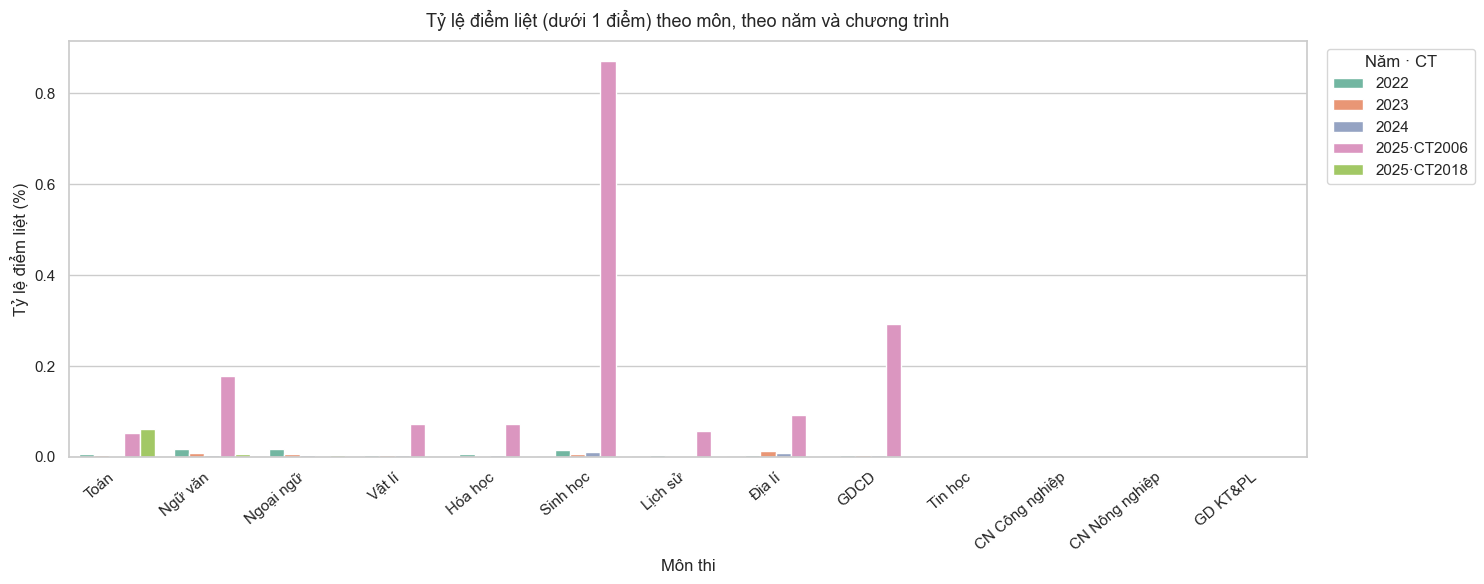

In [27]:
viz.plot_fail_rate_by_subject(df)
plt.show()

**Nhận xét, tỷ lệ điểm liệt theo môn.**

Tỷ lệ điểm liệt (dưới 1 điểm) ở các năm chính quy 2022, 2023 và 2024 nhìn chung rất thấp, hầu hết các môn đều dưới 0,02%, cho thấy số thí sinh bị điểm liệt chiếm tỷ lệ không đáng kể trong tổng số dự thi.

Khác biệt lớn nhất nằm ở nhóm thí sinh tự do năm 2025 theo chương trình 2006. Nhóm này có tỷ lệ điểm liệt cao vượt trội ở hầu hết các môn, đặc biệt là Sinh học với khoảng 0,86% và GDCD khoảng 0,29%, cao gấp nhiều lần so với thí sinh chính quy. Kết quả này phản ánh đúng tính chất của nhóm tự do, vốn có mặt bằng điểm thấp và không đại diện cho toàn bộ thí sinh dự thi, nên cần được tách riêng khi diễn giải.

Ở nhóm chương trình 2018 năm 2025, tỷ lệ điểm liệt vẫn ở mức thấp và chỉ tập trung ở một vài môn bắt buộc như Toán và Ngữ văn, tương đương mặt bằng của các năm chính quy trước đó.

Xét theo môn, Sinh học và Ngữ văn là hai môn có tỷ lệ điểm liệt nhỉnh hơn các môn còn lại một cách ổn định qua nhiều năm, tuy mức chênh lệch là rất nhỏ. Nhìn chung, ngoại trừ nhóm thí sinh tự do, hiện tượng điểm liệt không phải là vấn đề phổ biến trong kỳ thi.

## 3. Xu hướng qua năm
Theo dõi sự biến động của điểm trung bình qua giai đoạn 2022-2024 và năm bản lề 2025.

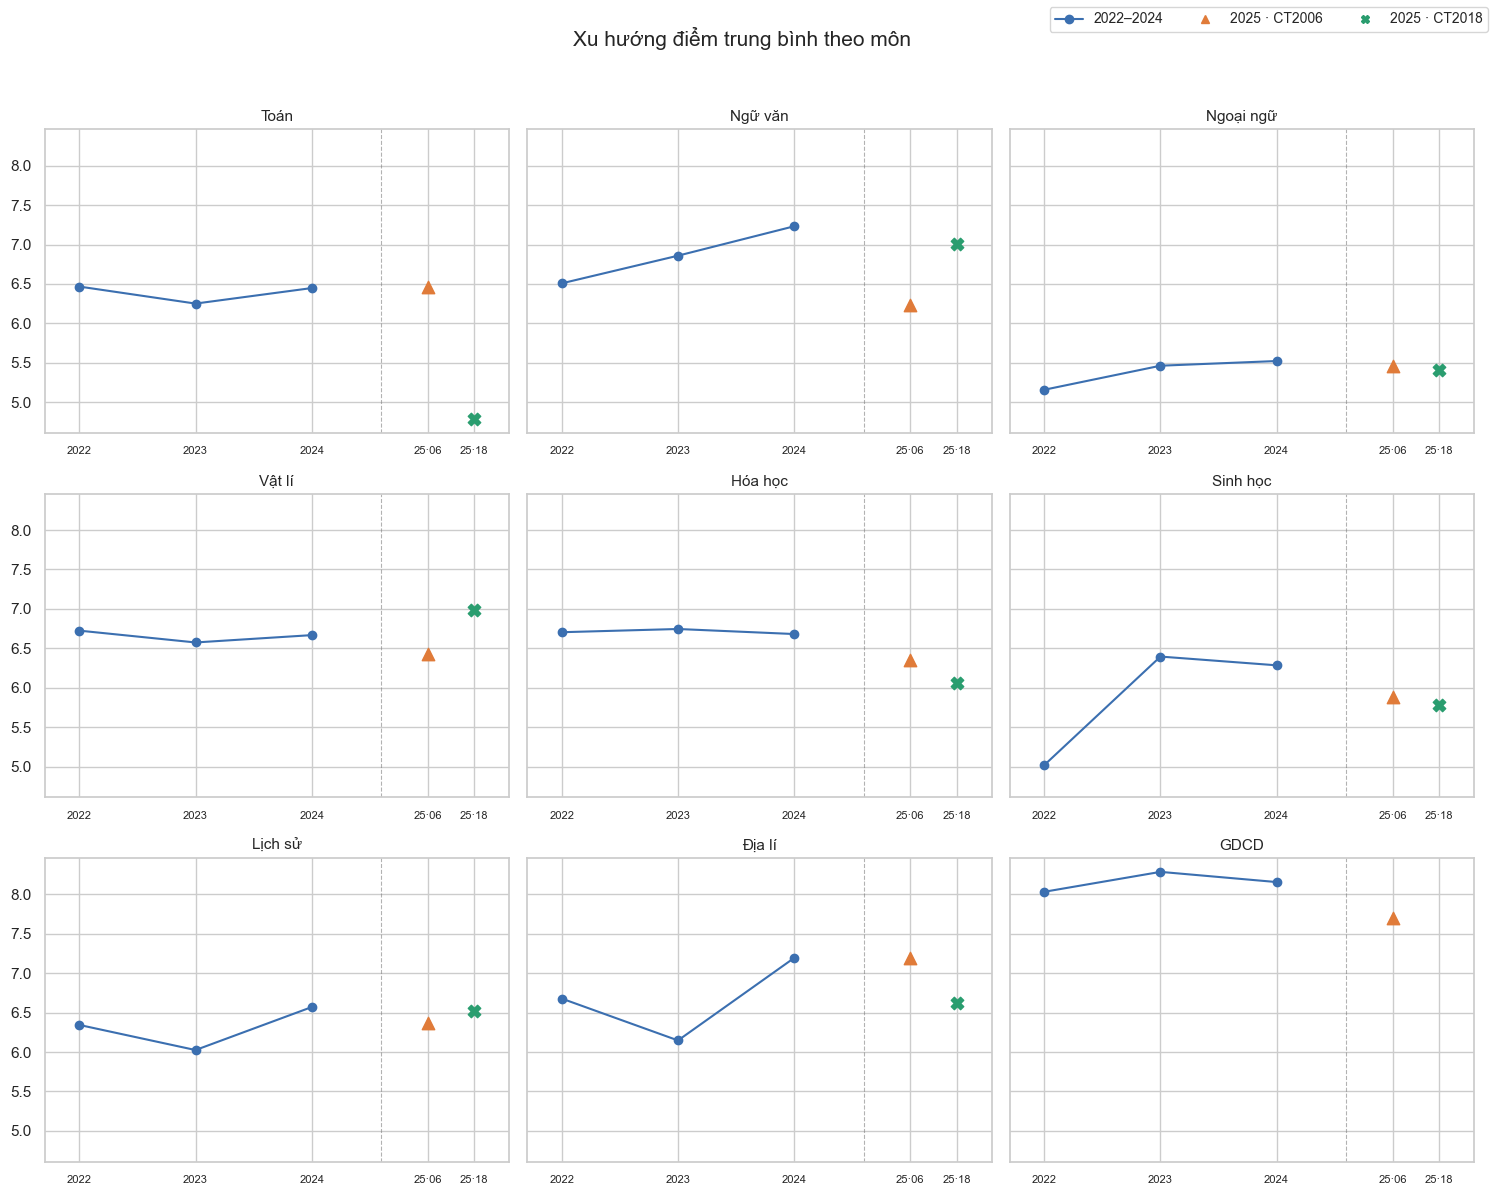

In [29]:
viz.plot_trend_2022_2024(df, stat="mean")
plt.show()

**Nhận xét, xu hướng điểm trung bình theo môn.**

Trong giai đoạn 2022 đến 2024, điểm trung bình các môn nhìn chung khá ổn định, dao động quanh mức 6 đến 7 điểm, không có biến động lớn. Một số môn có cải thiện rõ rệt: Ngữ văn tăng đều qua từng năm, từ khoảng 6,5 lên hơn 7,2; Sinh học và Địa lí tăng mạnh sau khi giảm ở năm 2023. GDCD duy trì vị trí môn có điểm trung bình cao nhất, ổn định quanh mức 8 điểm. Ngoại ngữ là môn có mặt bằng thấp nhất trong nhóm, dù có nhích nhẹ qua các năm vẫn chỉ quanh mức 5,5.

Năm 2025 được tách riêng và không nối vào đường xu hướng do thay đổi chương trình và đề thi. So sánh giữa hai nhóm thí sinh năm 2025 cho thấy sự chênh lệch đáng chú ý. Nhóm chương trình 2018 thường có điểm trung bình cao hơn nhóm tự do chương trình 2006 ở phần lớn các môn, rõ nhất ở Ngữ văn, Vật lí và Địa lí. Điều này phù hợp với đặc điểm nhóm tự do vốn có mặt bằng điểm thấp hơn.

Riêng môn Toán đi ngược xu hướng chung: điểm trung bình của nhóm chương trình 2018 năm 2025 giảm xuống dưới 5, thấp hơn hẳn mặt bằng 6 đến 6,5 của các năm trước và thấp hơn cả nhóm tự do cùng năm. Đây là tín hiệu cho thấy đề Toán theo chương trình mới có độ khó cao hơn, là điểm đáng lưu ý khi phân tích năm bản lề.

Cần nhắc lại rằng các giá trị năm 2025 không so sánh trực tiếp với giai đoạn 2022 đến 2024 về mặt thước đo, do khác biệt về cấu trúc đề thi và chương trình. Các so sánh ở trên chỉ mang tính mô tả tương quan, không phản ánh mức độ tiến bộ hay giảm sút thực chất của thí sinh.

## 4. Địa lý

So sánh sự khác biệt về kết quả thi giữa các tỉnh.

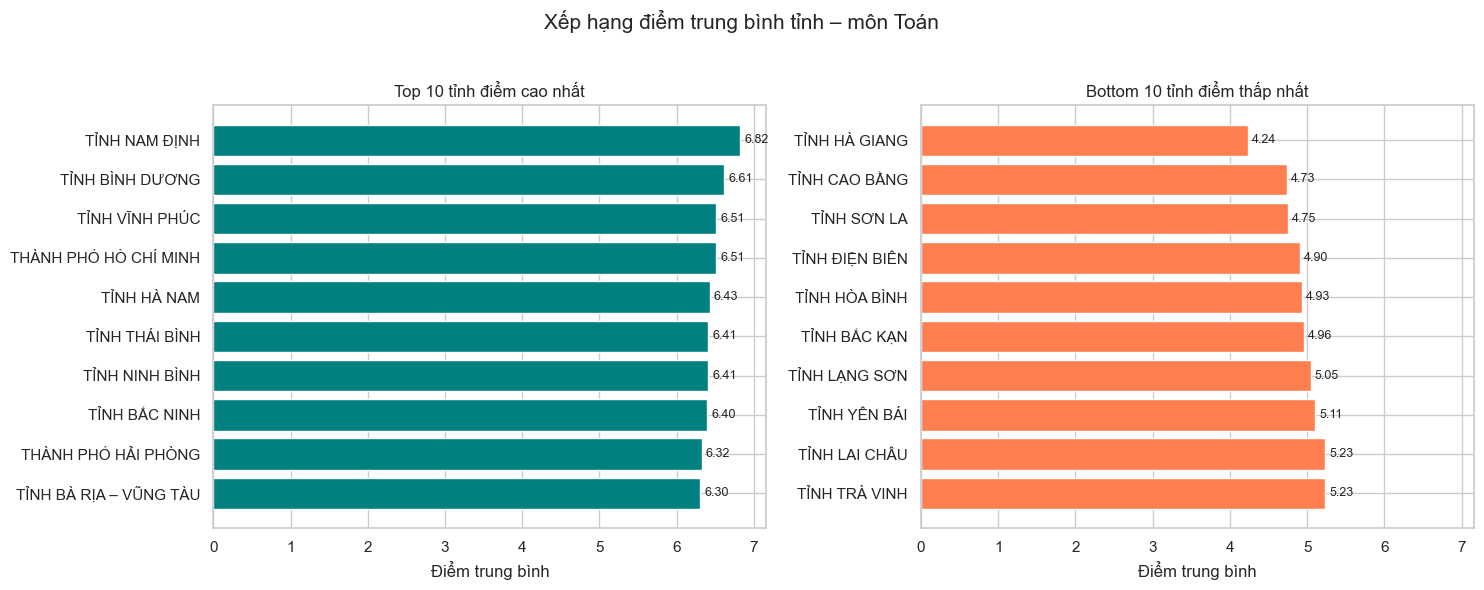

In [32]:
viz.plot_province_rank(df, subject="toan", top=10)
plt.show()

**Nhận xét, xếp hạng tỉnh theo điểm trung bình môn Toán.**

Kết quả cho thấy sự phân hóa địa lý khá rõ về điểm trung bình môn Toán giữa các tỉnh. Nhóm dẫn đầu chủ yếu là các tỉnh, thành thuộc đồng bằng sông Hồng và vùng Đông Nam Bộ, với Nam Định cao nhất cả nước (6,82 điểm), tiếp theo là Bình Dương, Vĩnh Phúc và Thành phố Hồ Chí Minh. Đây đều là những địa phương có điều kiện kinh tế, xã hội và truyền thống giáo dục thuận lợi.

Ở chiều ngược lại, nhóm cuối bảng tập trung gần như hoàn toàn ở các tỉnh miền núi phía Bắc như Hà Giang, Cao Bằng, Sơn La, Điện Biên, Hòa Bình và Bắc Kạn. Hà Giang có điểm trung bình thấp nhất, chỉ khoảng 4,24 điểm.

Khoảng cách giữa tỉnh cao nhất và thấp nhất lên tới khoảng 2,6 điểm trên thang 10, là mức chênh lệch đáng kể đối với một môn thi bắt buộc mà gần như toàn bộ thí sinh đều dự thi. Sự tương phản này phản ánh khác biệt về điều kiện học tập giữa khu vực đồng bằng, đô thị và khu vực miền núi.

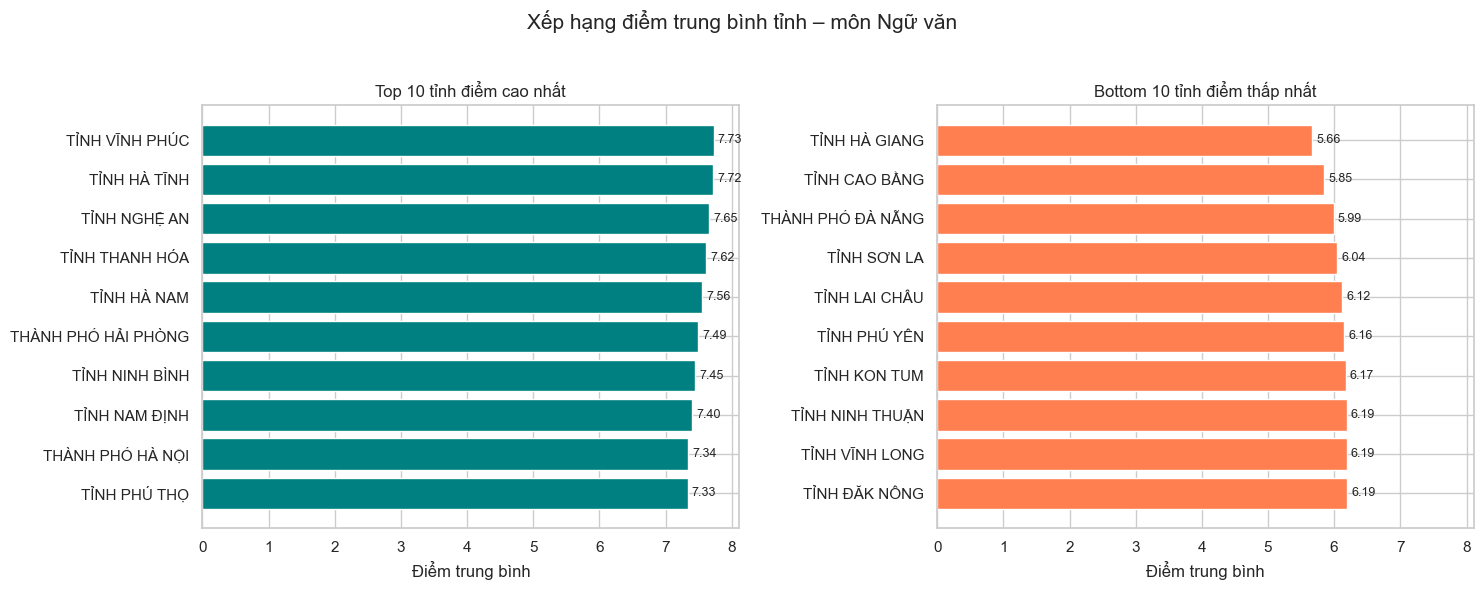

In [33]:
viz.plot_province_rank(df, subject="ngu_van", top=10)
plt.show()

**Nhận xét, xếp hạng tỉnh theo điểm trung bình môn Ngữ văn.**

So với môn Toán, mức chênh lệch điểm trung bình môn Ngữ văn giữa các tỉnh hẹp hơn nhiều, dao động từ khoảng 5,66 đến 7,73 điểm, tức chỉ khoảng 2 điểm giữa tỉnh cao nhất và thấp nhất. Mặt bằng điểm chung cũng cao hơn, phản ánh đặc thù môn tự luận với phổ điểm tập trung quanh vùng trung bình khá.

Nhóm dẫn đầu có sự thay đổi rõ rệt về cơ cấu vùng miền. Bên cạnh các tỉnh đồng bằng sông Hồng như Vĩnh Phúc, Hà Nam, Hải Phòng và Hà Nội, nhóm đầu bảng năm nay có thêm nhiều tỉnh Bắc Trung Bộ như Hà Tĩnh, Nghệ An và Thanh Hóa, vốn là những địa phương có truyền thống học tốt các môn xã hội. Vĩnh Phúc tiếp tục giữ vị trí cao, đứng đầu với 7,73 điểm.

Nhóm cuối bảng vẫn chủ yếu là các tỉnh miền núi phía Bắc như Hà Giang, Cao Bằng, Sơn La và Lai Châu, tương tự môn Toán, cho thấy nhóm này có mặt bằng điểm thấp ổn định ở cả môn tự nhiên lẫn xã hội. Một điểm đáng chú ý là Thành phố Đà Nẵng xuất hiện trong nhóm điểm thấp của môn Ngữ văn, khác với hình ảnh thường thấy của các thành phố lớn ở môn Toán, gợi ý sự khác biệt về thế mạnh môn học giữa các địa phương.

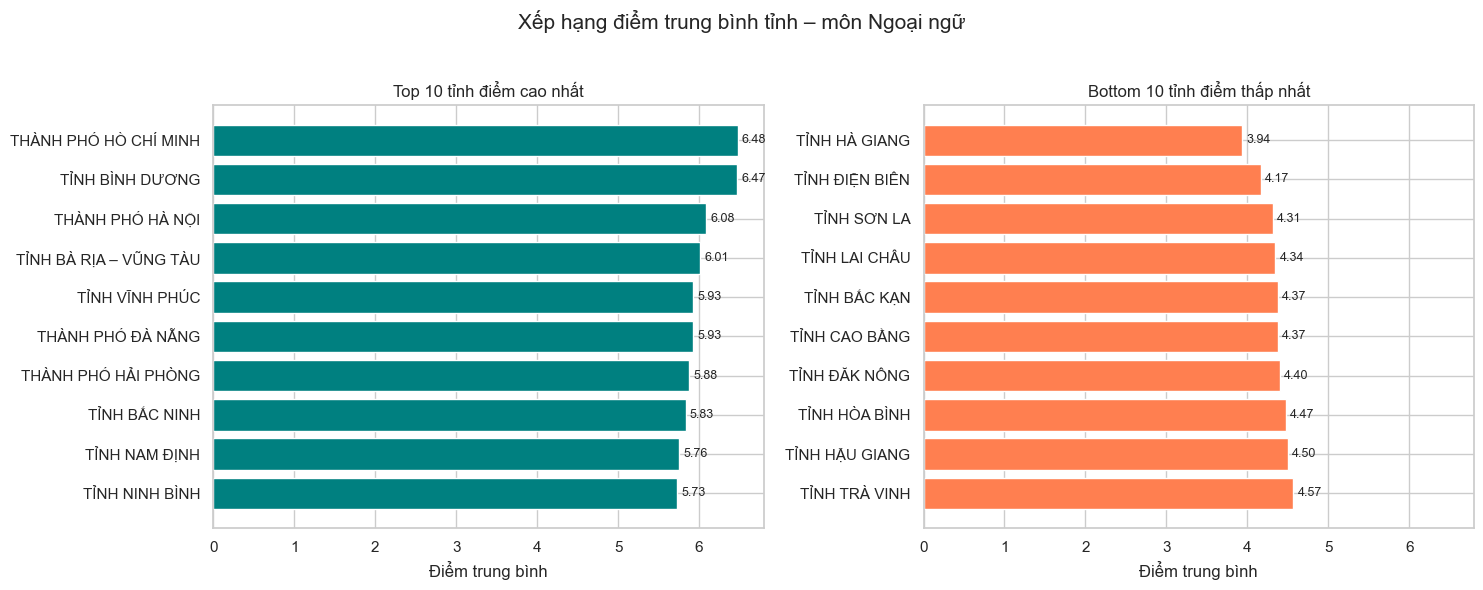

In [35]:
viz.plot_province_rank(df, subject="ngoai_ngu", top=10)
plt.show()
# chỉ tính N1 – tiếng Anh

**Nhận xét, xếp hạng tỉnh theo điểm trung bình môn Ngoại ngữ (tiếng Anh).**

Để đảm bảo so sánh đồng nhất, biểu đồ chỉ tính trên các thí sinh thi tiếng Anh (mã N1), loại bỏ các thứ tiếng khác và các tỉnh có quá ít thí sinh dự thi.

Môn Ngoại ngữ thể hiện sự phân hóa địa lý rõ rệt và mang tính phân tầng nhất trong các môn đã xét. Nhóm dẫn đầu gần như tuyệt đối là các đô thị lớn và tỉnh công nghiệp phát triển: Thành phố Hồ Chí Minh và Bình Dương cùng đạt khoảng 6,48 điểm, tiếp theo là Hà Nội, Bà Rịa Vũng Tàu, Đà Nẵng và Hải Phòng. Đây đều là những địa phương có điều kiện tiếp cận tiếng Anh thuận lợi và nhu cầu sử dụng ngoại ngữ cao.

Nhóm cuối bảng tập trung hoàn toàn ở các tỉnh miền núi phía Bắc và một số tỉnh đồng bằng sông Cửu Long như Hà Giang, Điện Biên, Sơn La, Lai Châu, Hậu Giang và Trà Vinh. Hà Giang tiếp tục đứng cuối với chỉ 3,94 điểm.

Khoảng cách giữa nhóm đầu và nhóm cuối lên tới khoảng 2,5 điểm, mức chênh lệch lớn nhất và nhất quán nhất trong các môn. Điều này cho thấy Ngoại ngữ là môn phản ánh rõ nhất sự bất bình đẳng về điều kiện học tập giữa khu vực đô thị, công nghiệp và khu vực miền núi, nông thôn.

## 5. Tương quan
Khám phá mức độ tương quan tuyến tính giữa các cặp môn học.

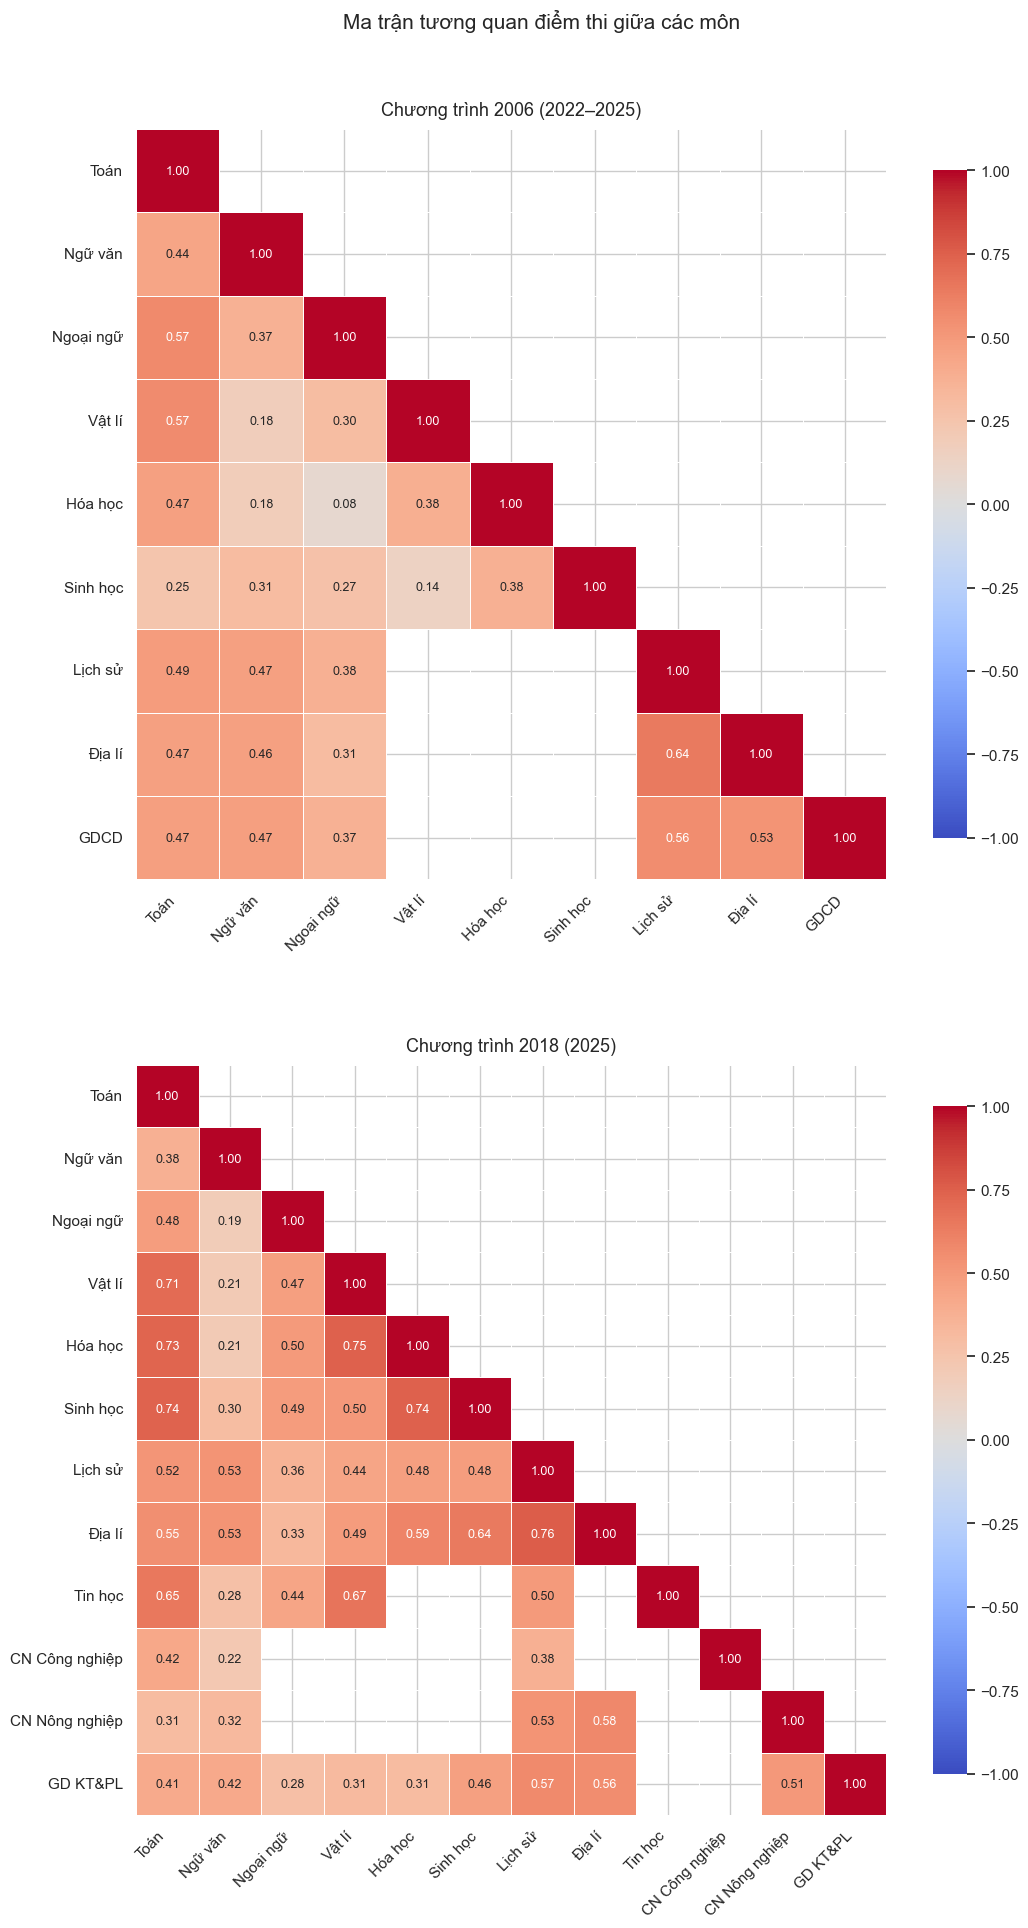

In [42]:
viz.plot_corr_heatmap(df)
plt.show()

**Nhận xét, tương quan điểm thi giữa các môn.**

Ma trận tương quan được tách riêng theo từng chương trình để tránh ghép nhầm hai nhóm thí sinh khác nhau. Các ô để trắng là những cặp môn có quá ít thí sinh cùng dự thi, không đủ cơ sở để tính tương quan.

Ở chương trình 2006, có thể thấy rõ hai cụm môn tương ứng với hai ban. Trong nhóm khoa học xã hội, Lịch sử, Địa lí và GDCD tương quan với nhau ở mức trung bình khá (Lịch sử với Địa lí đạt 0,64), phản ánh việc thí sinh chọn trọn một tổ hợp. Nhóm khoa học tự nhiên gồm Vật lí, Hóa học và Sinh học có tương quan nội bộ yếu hơn nhiều so với kỳ vọng, chỉ quanh 0,14 đến 0,38. Đáng chú ý, các ô chéo ban giữa nhóm tự nhiên và nhóm xã hội để trắng, do thí sinh chương trình 2006 hầu như chỉ thi một trong hai tổ hợp, rất ít người thi cả hai.

Toán đóng vai trò liên kết, có tương quan dương ổn định với hầu hết các môn, mạnh nhất với Ngoại ngữ và Vật lí (cùng khoảng 0,57). Sinh học là môn có tương quan thấp nhất với các môn còn lại, cho thấy điểm Sinh ít gắn với năng lực chung của thí sinh.

Ở chương trình 2018, mức độ tương quan giữa các môn nhìn chung cao và đồng đều hơn hẳn. Nhóm khoa học tự nhiên gắn kết chặt hơn nhiều so với chương trình cũ: Toán với Hóa học đạt 0,73, Toán với Sinh học 0,74, Vật lí với Hóa học 0,75. Nhóm khoa học xã hội cũng tương quan mạnh, với Lịch sử và Địa lí lên tới 0,76, mức cao nhất toàn bảng. Điều này cho thấy cấu trúc đề và cách chọn môn của chương trình mới tạo ra sự phân nhóm năng lực rõ ràng và nhất quán hơn.

Nhìn chung, ở cả hai chương trình, các cặp môn cùng lĩnh vực có tương quan cao hơn các cặp môn khác lĩnh vực, phù hợp với phân nhóm tự nhiên và xã hội. Tuy nhiên không có cặp môn nào đạt tương quan rất cao trên 0,8, cho thấy điểm các môn vẫn phản ánh những năng lực tương đối độc lập với nhau.

## 6. Lựa chọn tổ hợp theo vùng
Quan sát tỉ lệ lựa chọn ban (KHTN/KHXH) đối với CT2006 và tỉ lệ đăng ký các môn tự chọn mới đối với CT2018.

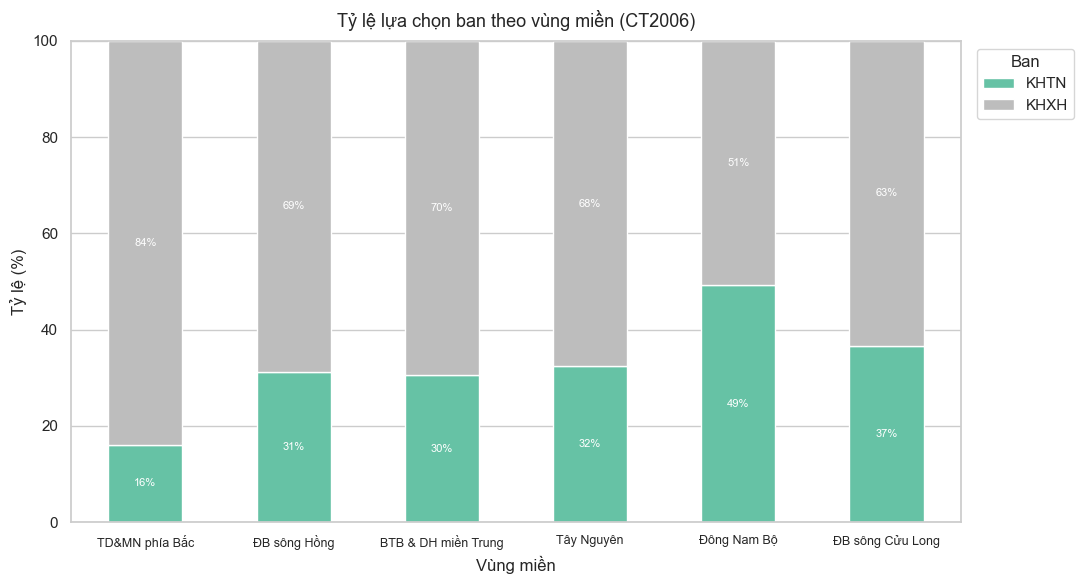

In [44]:
viz.plot_ban_by_region(df)
plt.show()

**Nhận xét, tỷ lệ lựa chọn ban theo vùng miền (CT2006).**

Biểu đồ cho thấy sự phân hóa rõ rệt trong xu hướng chọn ban giữa các vùng miền. Trên cả nước, ban khoa học xã hội chiếm ưu thế, nhưng mức độ chênh lệch giữa các vùng khác nhau đáng kể.

Trung du và miền núi phía Bắc là vùng nghiêng về khoa học xã hội mạnh nhất, với 84% thí sinh chọn ban này và chỉ 16% chọn khoa học tự nhiên, tạo nên khoảng cách lớn nhất trong sáu vùng. Các vùng Đồng bằng sông Hồng, Bắc Trung Bộ và Duyên hải miền Trung, cùng Tây Nguyên có cơ cấu khá tương đồng, với tỷ lệ chọn khoa học tự nhiên dao động quanh 30 đến 32%.

Ở chiều ngược lại, Đông Nam Bộ là vùng có tỷ lệ chọn khoa học tự nhiên cao nhất, gần như cân bằng giữa hai ban với 49% chọn tự nhiên và 51% chọn xã hội. Đồng bằng sông Cửu Long đứng thứ hai về xu hướng này với 37% chọn tự nhiên.

Có thể thấy hai vùng kinh tế phát triển nhất ở phía Nam là Đông Nam Bộ và Đồng bằng sông Cửu Long có tỷ lệ chọn ban khoa học tự nhiên cao hơn rõ rệt so với các vùng còn lại, trong khi khu vực miền núi phía Bắc nghiêng hẳn về khoa học xã hội. Xu hướng này gợi ý mối liên hệ giữa định hướng chọn tổ hợp môn và đặc điểm kinh tế, xã hội của từng vùng, có thể phản ánh sự khác biệt về điều kiện học tập các môn tự nhiên cũng như định hướng nghề nghiệp giữa các địa phương.

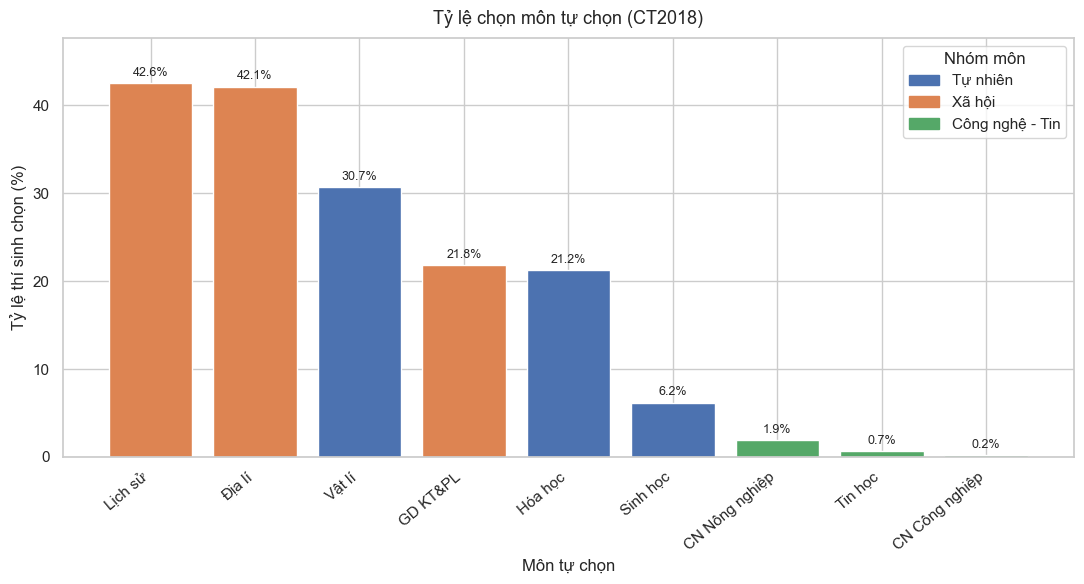

In [46]:
viz.plot_ct2018_subject_uptake(df)
plt.show()

**Nhận xét, tỷ lệ chọn môn tự chọn (CT2018).**

Trong chương trình 2018, thí sinh chọn hai môn tự chọn ngoài hai môn bắt buộc Toán và Ngữ văn. Cơ cấu lựa chọn cho thấy sự phân hóa rõ rệt giữa các môn.

Hai môn được chọn nhiều nhất là Lịch sử (42,6%) và Địa lí (42,1%), bỏ xa các môn còn lại. Tiếp theo là Vật lí (30,7%), trong khi GD kinh tế và pháp luật cùng Hóa học ở mức tương đương nhau, quanh 21%. Như vậy nhóm môn xã hội tiếp tục chiếm ưu thế, tương tự xu hướng nghiêng về khoa học xã hội đã thấy ở chương trình 2006.

Đáng chú ý là sự sụt giảm mạnh ở nhóm cuối. Sinh học chỉ được 6,2% thí sinh lựa chọn, thấp hơn hẳn hai môn tự nhiên còn lại là Vật lí và Hóa học, cho thấy Sinh học là môn kém hấp dẫn nhất trong nhóm khoa học tự nhiên. Ba môn mới của chương trình 2018 gồm Công nghệ nông nghiệp (1,9%), Tin học (0,7%) và Công nghệ công nghiệp (0,2%) có tỷ lệ chọn rất thấp, gần như không đáng kể.

Tỷ lệ lựa chọn quá thấp của các môn mới cho thấy trong năm đầu áp dụng, thí sinh vẫn ưu tiên các môn truyền thống quen thuộc và phục vụ xét tuyển đại học, trong khi các môn mới chưa thực sự phổ biến. Đây cũng là lý do cần thận trọng khi phân tích điểm số của nhóm môn này, do quy mô thí sinh dự thi rất nhỏ.